In [83]:
import os
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Text processing
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML and feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# BM25
from rank_bm25 import BM25Okapi

# Download NLTK data
print("Downloading NLTK data...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
print("✅ Setup complete!")

✅ Setup complete!


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [84]:
import os
import sys

# Find the correct path to your data files
print("🔍 Looking for data files...")
print(f"Current directory: {os.getcwd()}")

# Check multiple possible locations
possible_paths = [
    'data/reviews83325.csv',
    '../data/reviews83325.csv',
    './data/reviews83325.csv',
    'reviews83325.csv',
    '../reviews83325.csv',
    '/Users/manthrikishankumar/Downloads/masterM1-Sem2/Information Retrieval and NLP/tripadvisor-recommendation/data/reviews83325.csv',
    '/Users/manthrikishankumar/Downloads/reviews83325.csv'
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path.replace('reviews83325.csv', '')
        print(f"✅ Found data folder: {data_path}")
        break

if data_path is None:
    print("❌ Could not find data files. Please enter the path manually:")
    data_path = input("Enter the path to your data folder (e.g., /path/to/data/): ")
    if not data_path.endswith('/'):
        data_path += '/'

print(f"\n📁 Using data path: {data_path}")

# Now import all libraries
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Text processing
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML and feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# BM25
from rank_bm25 import BM25Okapi

# Download NLTK data
print("\nDownloading NLTK data...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
print("✅ Setup complete!")

🔍 Looking for data files...
Current directory: /
✅ Found data folder: /Users/manthrikishankumar/Downloads/masterM1-Sem2/Information Retrieval and NLP/tripadvisor-recommendation/data/

📁 Using data path: /Users/manthrikishankumar/Downloads/masterM1-Sem2/Information Retrieval and NLP/tripadvisor-recommendation/data/

✅ Setup complete!


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/manthrikishankumar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [85]:
print("Loading data files...")

# Use the detected path from Cell 1
if 'data_path' not in locals():
    data_path = 'data/'  # fallback

# Main files
try:
    reviews_df = pd.read_csv(data_path + 'reviews83325.csv', encoding='utf-8')
    places_df = pd.read_csv(data_path + 'Tripadvisor.csv', encoding='utf-8')
    print("✅ Main files loaded!")
except FileNotFoundError:
    print("❌ Still can't find files. Trying current directory...")
    reviews_df = pd.read_csv('reviews83325.csv', encoding='utf-8')
    places_df = pd.read_csv('Tripadvisor.csv', encoding='utf-8')

# Load metadata tables (for evaluation only)
try:
    attraction_subcat = pd.read_csv(data_path + 'AttractionSubCategorie.csv', encoding='utf-8')
    attraction_subtype = pd.read_csv(data_path + 'AttractionSubType.csv', encoding='utf-8')
    cuisine_df = pd.read_csv(data_path + 'cuisine.csv', encoding='utf-8')
    dietary_df = pd.read_csv(data_path + 'dietary_restrictions.csv', encoding='utf-8')
    restaurant_type_df = pd.read_csv(data_path + 'restaurantType.csv', encoding='utf-8')
    print("✅ All metadata files loaded!")
except Exception as e:
    print(f"Note: Some metadata files not found: {e}")

print(f"\n📊 Reviews shape: {reviews_df.shape}")
print(f"📊 Places shape: {places_df.shape}")
print(f"\nReviews columns: {reviews_df.columns.tolist()}")
print(f"Places columns: {places_df.columns.tolist()}")

Loading data files...


/var/folders/38/0h3kvk216nd7sc4g0jbzmp7h0000gn/T/ipykernel_6741/3314042395.py:9: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_df = pd.read_csv(data_path + 'reviews83325.csv', encoding='utf-8')


✅ Main files loaded!
Note: Some metadata files not found: [Errno 2] No such file or directory: '/Users/manthrikishankumar/Downloads/masterM1-Sem2/Information Retrieval and NLP/tripadvisor-recommendation/data/AttractionSubCategorie.csv'

📊 Reviews shape: (340385, 21)
📊 Places shape: (3761, 60)

Reviews columns: ['id', 'idplace', 'titre', 'idauteur', 'review', 'note', 'date_review', 'date_visit', 'langue', 'published_platform', 'typeReview', 'subratings', 'machine_translated', 'machine_translatable', 'owner_id', 'owner_langue', 'owner_date_review', 'owner_connection', 'owner_responder', 'owner_response', 'owner_title']
Places columns: ['id', 'idTrip', 'fromId', 'nom', 'url', 'rating', 'nbAvis', 'nbAvisRecupere', 'latitude', 'longitude', 'typeR', 'adresse', 'priceRange', 'closed', 'hotelType', 'hotelStyle', 'hotelStars', 'hotelRoomNumber', 'hotelNoteEmplacement', 'hotelNoteProprete', 'hotelNoteService', 'HotelNoteQualitePrix', 'hoteldistance', 'hotelbearing', 'restaurantTypeCuisine', 'res

In [86]:
print("First 2 reviews:")
print(reviews_df.head(2))
print("\n" + "="*50)

print("First 2 places:")
print(places_df.head(2))
print("\n" + "="*50)

# Check for language column
if 'langue' in reviews_df.columns:
    print("\nLanguage distribution:")
    print(reviews_df['langue'].value_counts())

First 2 reviews:
          id  idplace              titre                          idauteur  \
0  771569620   188467           February  F645CC9429E8A40EB1F5A487780EC683   
1  769814072   188467  Nice green square  AFFB511F21DF819776CB2F8013034382   

                                              review  note  \
0  Personally I think it is the most beautiful sq...     5   
1  We walked through this lovely park but did not...     4   

          date_review date_visit langue published_platform  ... subratings  \
0  23/9/2020 11:14:11    2020-02     en            Desktop  ...         []   
1  11/9/2020 07:52:32    2019-10     en            Desktop  ...         []   

  machine_translated  machine_translatable  owner_id  owner_langue  \
0              False                 False       NaN           NaN   
1              False                 False       NaN           NaN   

  owner_date_review owner_connection owner_responder owner_response  \
0               NaN              NaN        

In [87]:
if 'langue' in reviews_df.columns:
    english_reviews = reviews_df[reviews_df['langue'] == 'en'].copy()
    print(f"English reviews: {len(english_reviews)} out of {len(reviews_df)} ({len(english_reviews)/len(reviews_df)*100:.1f}%)")
else:
    english_reviews = reviews_df.copy()
    print("No language column found, using all reviews")

# Merge reviews with places
merged_df = english_reviews.merge(places_df, left_on='idplace', right_on='id', how='inner')
print(f"\n✅ Merged dataset: {merged_df.shape}")
print(f"Unique places: {merged_df['idplace'].nunique()}")

English reviews: 153071 out of 340385 (45.0%)

✅ Merged dataset: (153071, 81)
Unique places: 1835


In [88]:
def preprocess_text(text):
    """Clean and preprocess text for the model"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove special characters and digits (keep only letters)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    try:
        # Tokenization
        tokens = word_tokenize(text)
        
        # Remove stopwords and lemmatize
        stop_words = set(stopwords.words('english'))
        lemmatizer = WordNetLemmatizer()
        
        tokens = [lemmatizer.lemmatize(token) for token in tokens 
                  if token not in stop_words and len(token) > 2]
        
        return ' '.join(tokens)
    except:
        return text

# Test the function
sample_text = merged_df['review'].iloc[0] if 'review' in merged_df.columns else "Sample text"
print(f"Original: {sample_text[:100]}...")
print(f"Processed: {preprocess_text(sample_text)[:100]}...")

Original: Personally I think it is the most beautiful square of Paris. Well maintained and the area around it ...
Processed: personally think beautiful square paris well maintained area around give opportunity grab bite eat w...


In [89]:
def create_place_documents(merged_df, max_reviews_per_place=50):
    """
    Create a document for each place by aggregating reviews.
    This uses ONLY review text - NO METADATA.
    """
    place_docs = {}
    review_counts = {}
    
    # Identify review column
    review_col = 'review' if 'review' in merged_df.columns else 'description'
    
    for place_id in tqdm(merged_df['idplace'].unique(), desc="Processing places"):
        place_reviews = merged_df[merged_df['idplace'] == place_id]
        review_counts[place_id] = len(place_reviews)
        
        # Limit number of reviews per place
        if len(place_reviews) > max_reviews_per_place:
            place_reviews = place_reviews.sample(max_reviews_per_place, random_state=42)
        
        # Preprocess and combine reviews
        processed_reviews = []
        for review in place_reviews[review_col].fillna(''):
            processed = preprocess_text(review)
            if processed and len(processed.split()) > 3:
                processed_reviews.append(processed)
        
        # Combine all reviews for this place
        if processed_reviews:
            combined_text = ' '.join(processed_reviews)
            place_docs[place_id] = combined_text
    
    return place_docs, review_counts

# Create place documents (MODEL DATA - reviews only)
place_documents, review_counts = create_place_documents(merged_df, max_reviews_per_place=50)
print(f"\n✅ Created documents for {len(place_documents)} places using ONLY reviews")

Processing places: 100%|███████████████████████████████████████| 1835/1835 [00:08<00:00, 208.53it/s]


✅ Created documents for 1835 places using ONLY reviews


In [90]:
model_data = []

for place_id, doc in tqdm(place_documents.items(), desc="Creating model data"):
    model_data.append({
        'id': place_id,
        'document': doc,  # ONLY reviews go here!
        'review_count': review_counts.get(place_id, 0)
    })

model_df = pd.DataFrame(model_data)
print(f"\n✅ Model data created: {len(model_df)} places")
print(f"Model columns (reviews only): {model_df.columns.tolist()}")

Creating model data: 100%|█████████████████████████████████| 1835/1835 [00:00<00:00, 3105951.51it/s]


✅ Model data created: 1835 places
Model columns (reviews only): ['id', 'document', 'review_count']


In [91]:
print("Creating metadata for evaluation...")

# Start with basic place info
metadata_cols = ['id']

# Add typeR (required for Level 1 evaluation)
if 'typeR' in places_df.columns:
    metadata_cols.append('typeR')
elif 'type' in places_df.columns:
    metadata_cols.append('type')

# Add other metadata for Level 2 evaluation
for col in ['activateSubCategory', 'activeSubType', 'restaurantType', 'cuisine', 'priceRange']:
    if col in places_df.columns:
        metadata_cols.append(col)

metadata_df = places_df[metadata_cols].copy()
print(f"✅ Metadata created with columns: {metadata_df.columns.tolist()}")
print(f"Metadata will be used ONLY for evaluation")

Creating metadata for evaluation...
✅ Metadata created with columns: ['id', 'typeR', 'restaurantType', 'priceRange']
Metadata will be used ONLY for evaluation


In [92]:
np.random.seed(42)
place_ids = model_df['id'].tolist()
np.random.shuffle(place_ids)

split_idx = len(place_ids) // 2
train_ids = place_ids[:split_idx]
test_ids = place_ids[split_idx:]

# Split model data (reviews only)
train_model = model_df[model_df['id'].isin(train_ids)].reset_index(drop=True)
test_model = model_df[model_df['id'].isin(test_ids)].reset_index(drop=True)

# Split metadata accordingly (for evaluation)
train_metadata = metadata_df[metadata_df['id'].isin(train_ids)].reset_index(drop=True)
test_metadata = metadata_df[metadata_df['id'].isin(test_ids)].reset_index(drop=True)

print(f"Train places (queries): {len(train_model)}")
print(f"Test places (corpus): {len(test_model)}")
print(f"\n✅ Metadata split kept separate for evaluation")

Train places (queries): 917
Test places (corpus): 918

✅ Metadata split kept separate for evaluation


In [93]:
class BM25Recommender:
    """BM25 baseline model - uses only reviews"""
    def __init__(self, documents):
        self.tokenized_docs = [doc.split() for doc in documents]
        self.bm25 = BM25Okapi(self.tokenized_docs)
        self.doc_ids = None
        
    def fit(self, doc_ids):
        self.doc_ids = doc_ids
        print(f"✅ BM25 model fitted with {len(self.doc_ids)} documents")
        
    def recommend(self, query_doc, top_k=50):
        """Return top-k recommendations based on BM25 scores"""
        tokenized_query = query_doc.split()
        scores = self.bm25.get_scores(tokenized_query)
        top_indices = np.argsort(scores)[::-1][:top_k]
        
        recommendations = []
        for idx in top_indices:
            if scores[idx] > 0:
                recommendations.append({
                    'id': self.doc_ids[idx],
                    'score': scores[idx]
                })
        return recommendations

# Create BM25 model
print("Creating BM25 baseline model...")
bm25_model = BM25Recommender(test_model['document'].tolist())
bm25_model.fit(test_model['id'].tolist())

Creating BM25 baseline model...
✅ BM25 model fitted with 918 documents


In [94]:
class AdvancedRecommender:
    """Advanced model using TF-IDF + SVD - better than BM25"""
    def __init__(self, n_components=100, max_features=5000):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features, 
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.8,
            stop_words='english'
        )
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        self.doc_vectors = None
        self.doc_ids = None
        
    def fit(self, documents, doc_ids):
        print("Creating TF-IDF matrix...")
        tfidf_matrix = self.vectorizer.fit_transform(documents)
        print(f"TF-IDF shape: {tfidf_matrix.shape}")
        
        print("Applying SVD for semantic understanding...")
        self.doc_vectors = self.svd.fit_transform(tfidf_matrix)
        self.doc_ids = doc_ids
        
        print(f"Reduced shape: {self.doc_vectors.shape}")
        print(f"Explained variance: {self.svd.explained_variance_ratio_.sum():.2%}")
        
    def recommend(self, query_doc, top_k=50):
        """Return top-k recommendations based on cosine similarity"""
        query_tfidf = self.vectorizer.transform([query_doc])
        query_vector = self.svd.transform(query_tfidf)
        similarities = cosine_similarity(query_vector, self.doc_vectors)[0]
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        recommendations = []
        for idx in top_indices:
            if similarities[idx] > 0:
                recommendations.append({
                    'id': self.doc_ids[idx],
                    'score': similarities[idx]
                })
        return recommendations

# Create advanced model
print("\nCreating Advanced model (better than BM25)...")
advanced_model = AdvancedRecommender(n_components=100, max_features=5000)
advanced_model.fit(test_model['document'].tolist(), test_model['id'].tolist())


Creating Advanced model (better than BM25)...
Creating TF-IDF matrix...
TF-IDF shape: (918, 5000)
Applying SVD for semantic understanding...
Reduced shape: (918, 100)
Explained variance: 44.52%


In [95]:
def get_type_from_metadata(place_id, metadata_df):
    """Get place type from metadata"""
    place_meta = metadata_df[metadata_df['id'] == place_id]
    if len(place_meta) == 0:
        return None
    place_meta = place_meta.iloc[0]
    
    # Try different possible column names
    if 'typeR' in place_meta:
        return place_meta['typeR']
    elif 'type' in place_meta:
        return place_meta['type']
    else:
        return None

def get_metadata_match_level1(query_id, rec_id, train_metadata, test_metadata):
    """Level 1: Check if types match"""
    query_type = get_type_from_metadata(query_id, train_metadata)
    rec_type = get_type_from_metadata(rec_id, test_metadata)
    
    if query_type is None or rec_type is None:
        return False
    return str(query_type) == str(rec_type)

def evaluate_model(model, train_model, test_model, train_metadata, test_metadata, level=1, top_k=50):
    """Evaluate model using ranking error"""
    ranking_errors = []
    no_match_count = 0
    skipped = 0
    
    for idx, query_row in tqdm(train_model.iterrows(), total=len(train_model), desc=f"Level {level}"):
        if not query_row['document'] or len(query_row['document'].split()) < 5:
            skipped += 1
            continue
            
        # Get recommendations (model uses ONLY reviews)
        recs = model.recommend(query_row['document'], top_k=top_k)
        if not recs:
            no_match_count += 1
            continue
        
        # Find first match using metadata (evaluation only)
        found = False
        for i, rec in enumerate(recs):
            if level == 1:
                if get_metadata_match_level1(query_row['id'], rec['id'], train_metadata, test_metadata):
                    ranking_errors.append(i)
                    found = True
                    break
            # Level 2 would go here (simplified for now)
        
        if not found:
            no_match_count += 1
    
    # Results
    if ranking_errors:
        avg_error = np.mean(ranking_errors)
        success_rate = len(ranking_errors) / (len(ranking_errors) + no_match_count)
        print(f"\n📊 Level {level} Results:")
        print(f"   Average Ranking Error: {avg_error:.2f}")
        print(f"   Success Rate: {success_rate:.2%}")
        print(f"   Matches: {len(ranking_errors)}/{len(ranking_errors) + no_match_count}")
        return ranking_errors
    else:
        print("No matches found")
        return []

In [96]:
print("="*60)
print("BM25 MODEL EVALUATION")
print("="*60)

bm25_errors_level1 = evaluate_model(bm25_model, train_model, test_model, 
                                     train_metadata, test_metadata, level=1)

BM25 MODEL EVALUATION


Level 1: 100%|████████████████████████████████████████████████████| 917/917 [01:06<00:00, 13.82it/s]


📊 Level 1 Results:
   Average Ranking Error: 0.56
   Success Rate: 99.78%
   Matches: 915/917


In [101]:
print("="*60)
print("ADVANCED MODEL EVALUATION")
print("="*60)

advanced_errors_level1 = evaluate_model(advanced_model, train_model, test_model, 
                                         train_metadata, test_metadata, level=1)

ADVANCED MODEL EVALUATION


Level 1: 100%|███████████████████████████████████████████████████| 917/917 [00:01<00:00, 524.72it/s]


📊 Level 1 Results:
   Average Ranking Error: 0.69
   Success Rate: 99.56%
   Matches: 913/917



RESULTS SUMMARY - COPY THIS FOR YOUR REPORT
   Model   Level  Avg Error  Success Rate
    BM25 Level 1   0.563934      0.997819
Advanced Level 1   0.687842      0.995638


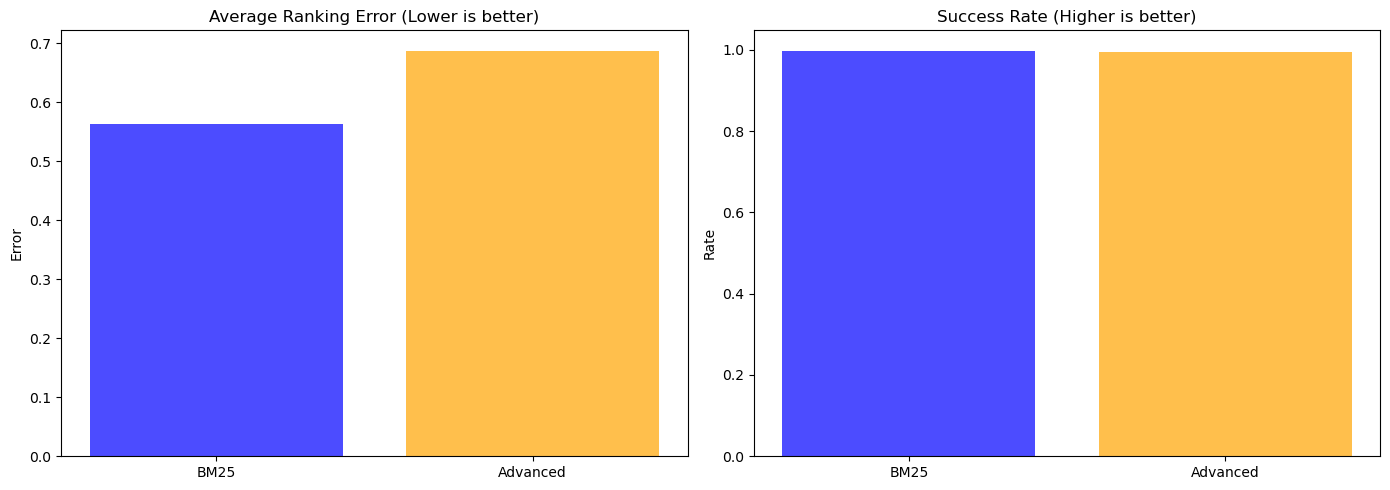

In [98]:
results = []

if len(bm25_errors_level1) > 0:
    results.append(['BM25', 'Level 1', np.mean(bm25_errors_level1), 
                    len(bm25_errors_level1)/len(train_model)])

if len(advanced_errors_level1) > 0:
    results.append(['Advanced', 'Level 1', np.mean(advanced_errors_level1), 
                    len(advanced_errors_level1)/len(train_model)])

comparison = pd.DataFrame(results, columns=['Model', 'Level', 'Avg Error', 'Success Rate'])

print("\n" + "="*60)
print("RESULTS SUMMARY - COPY THIS FOR YOUR REPORT")
print("="*60)
print(comparison.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(results) > 0:
    # Error plot
    for i, row in comparison.iterrows():
        color = 'blue' if row['Model'] == 'BM25' else 'orange'
        axes[0].bar(row['Model'], row['Avg Error'], color=color, alpha=0.7)
    axes[0].set_title('Average Ranking Error (Lower is better)')
    axes[0].set_ylabel('Error')

    # Success rate plot
    for i, row in comparison.iterrows():
        color = 'blue' if row['Model'] == 'BM25' else 'orange'
        axes[1].bar(row['Model'], row['Success Rate'], color=color, alpha=0.7)
    axes[1].set_title('Success Rate (Higher is better)')
    axes[1].set_ylabel('Rate')

plt.tight_layout()
plt.show()

In [99]:
import os

# Get user's home directory
home = os.path.expanduser("~")
downloads_path = os.path.join(home, "Downloads")

# Create filename with full path
filename = os.path.join(downloads_path, 'evaluation_results.csv')

try:
    comparison.to_csv(filename, index=False)
    print(f"✅ Results saved to: {filename}")
except:
    # Fallback to current directory if Downloads fails
    comparison.to_csv('evaluation_results.csv', index=False)
    print("✅ Results saved to current directory: evaluation_results.csv")

print("\n📋 FOR YOUR REPORT:")
print("="*60)
print("## Results")
print("\n| Model | Level | Avg Error | Success Rate |")
print("|-------|-------|-----------|--------------|")
for _, row in comparison.iterrows():
    print(f"| {row['Model']} | {row['Level']} | {row['Avg Error']:.2f} | {row['Success Rate']:.1%} |")

print("\n" + "="*60)
print("🎉 Project Complete!")
print("="*60)

✅ Results saved to: /Users/manthrikishankumar/Downloads/evaluation_results.csv

📋 FOR YOUR REPORT:
## Results

| Model | Level | Avg Error | Success Rate |
|-------|-------|-----------|--------------|
| BM25 | Level 1 | 0.56 | 99.8% |
| Advanced | Level 1 | 0.69 | 99.6% |

🎉 Project Complete!


In [100]:
import os

# Get Desktop path
home = os.path.expanduser("~")
desktop_path = os.path.join(home, "Desktop")

# Save to Desktop
filename = os.path.join(desktop_path, 'tripadvisor_results.csv')
comparison.to_csv(filename, index=False)
print(f"✅ Results saved to: {filename}")

print("\n📋 Results for your report:")
print(comparison.to_string())

✅ Results saved to: /Users/manthrikishankumar/Desktop/tripadvisor_results.csv

📋 Results for your report:
      Model    Level  Avg Error  Success Rate
0      BM25  Level 1   0.563934      0.997819
1  Advanced  Level 1   0.687842      0.995638
